**Business Question**

**Can customer segments derived independently from customer characteristics be shown to be internally valid, statistically distinct, significantly associated with churn, and sufficiently actionable for differentiated retention strategies?**

## Project Pipeline Overview

This notebook outlines a 12-phase project pipeline for customer segmentation, focusing on identifying distinct customer groups and understanding their relationship with churn. The primary goal is to derive actionable insights for differentiated retention strategies.

### Imports

This cell imports all necessary libraries for data manipulation, visualization, and clustering algorithms used throughout the project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

## Phase 1: Prepare the Data

This phase involves loading the customer churn dataset and performing initial data separation into features (X) and target (y).

### 1.1 Load Preprocessed Customer Churn Data

We load the preprocessed customer churn dataset from a parquet file. This dataset is already cleaned and scaled, making it ready for clustering.

In [2]:
df = pd.read_parquet('https://github.com/OmAditya19/Customer_Churn_App/raw/refs/heads/main/Data/preprocessed_data.parquet')

### 1.2 Separate Features and Target Variable

The loaded DataFrame `df` contains both the features used for clustering and the target variable 'Churn'. We separate these into `X` (features) and `y` (target) for model training and evaluation.

In [3]:
X = df.drop(columns=['Churn'])
y = df['Churn']

### 1.3 Display First Few Rows of Features

To ensure the data is loaded correctly and understand its structure, we display the first five rows of the feature set `X`.

In [4]:
X.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
0,0.255319,0.0,0.644068,0.735141,0.5,0.857440,0.444444,1.000000,0.969328,0.801661
1,1.000000,0.0,0.813559,0.000000,1.0,0.639846,0.000000,0.000000,0.745210,0.457073
2,0.787234,0.0,0.220339,0.334310,0.6,0.857440,0.000000,0.179104,0.266226,0.252896
3,0.851064,1.0,0.627119,0.874876,0.7,0.605547,0.444444,0.000000,0.596789,0.988037
4,0.106383,1.0,0.525424,0.857903,0.5,0.639846,0.000000,0.000000,0.789737,0.857903


## Phase 2: Prepare Features for K-means

This phase involved the necessary preprocessing steps to prepare the customer characteristics for K-means clustering. As indicated by the use of `preprocessed_data.parquet`, the data has already undergone scaling and encoding of features. This ensures that all features contribute equally to the distance calculations in K-means and prevents features with larger scales from dominating the clustering process.

## Phase 3: Find the Optimal Number of Clusters

This phase focuses on determining the optimal number of clusters (K) for K-means clustering. We evaluated various methods including the Elbow/WCSS curve, Silhouette Score, Calinski-Harabasz Score, and Davies-Bouldin Score to identify the most appropriate K value for our customer segmentation.

### 3.1 Determine Optimal K using the Elbow Method

The Elbow Method, using the `KElbowVisualizer` from `yellowbrick`, helps identify the optimal number of clusters by plotting the Sum of Squared Distances (SSE) against the number of clusters (K). The 'elbow' point on the curve indicates a diminishing return for increasing K, suggesting a suitable K value.

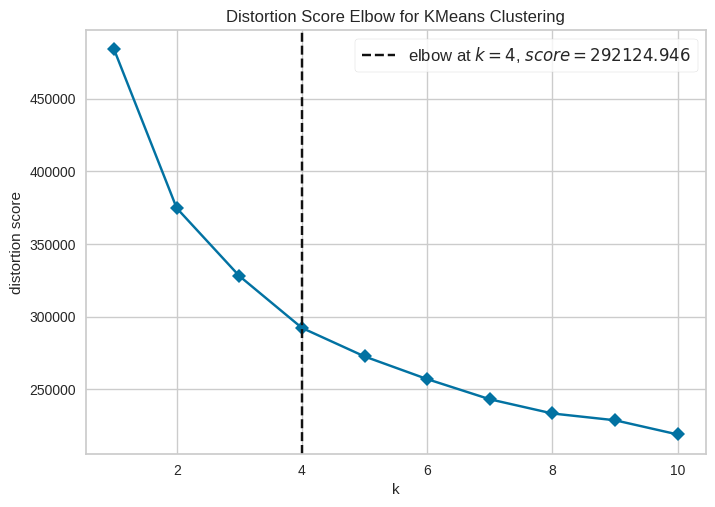


The automated elbow locator has mathematically confirmed optimal K = 4


In [5]:
# INITIALIZE BASE MODEL AND AUTOMATED VISUALIZER
# pass an untrained KMeans instance to the visualizer

model = KMeans(init="k-means++", random_state=42, n_init=10)
visualizer = KElbowVisualizer(model, k=(1, 11), timings=False)

# FIT THE DATA AND RENDER

visualizer.fit(X)        # Runs KMeans from k=1 to k=10 behind the scenes
visualizer.show()        # Generates the finalized annotated plot

# PROGRAMMATICALLY EXTRACT THE OPTIMAL K VALUE

optimal_k = visualizer.elbow_value_
print(f"\nThe automated elbow locator has mathematically confirmed optimal K = {optimal_k}")

### 3.2 Validate Optimal K with Clustering Metrics

While the Elbow Method provides a good starting point, it can sometimes be ambiguous. To further validate the optimal K, we evaluate clustering quality using objective metrics: Silhouette Score, Calinski-Harabasz Score, and Davies-Bouldin Score. These metrics offer quantitative insights into cluster cohesion and separation.

#### 3.2.1 Description of Metrics

*   **Silhouette Score**: Measures how similar an object is to its own cluster compared to other clusters. Higher values indicate better-defined clusters.
*   **Calinski-Harabasz Score (Variance Ratio Criterion)**: Measures the ratio of between-cluster variance to within-cluster variance. Higher values generally indicate better clustering.
*   **Davies-Bouldin Score**: Measures the average similarity ratio of each cluster with its most similar cluster. Lower values indicate better clustering.

Due to the computational intensity of the Silhouette Score for large datasets, a sampled subset of the data (`sampled_X`) is used for its calculation, as specified in the problem statement.

In [6]:
# Initialize lists to store the scores
silhouette_scores = []
calinski_harabasz_scores = []
davies_bouldin_scores = []
k_values = range(2, 11) # Start from k=2 as metrics are not defined for k=1

# Sample a subset of data for Silhouette Score calculation
# Using a small fraction (e.g., 10%) for performance
sampled_X = X.sample(frac=0.1, random_state=42)

for k in k_values:
    # Perform KMeans clustering
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    # Calculate Silhouette Score on sampled data
    # It's important to use the labels corresponding to the sampled data for the score calculation
    # So we'll predict labels for the sampled data too
    sampled_labels = kmeans.predict(sampled_X)
    silhouette_scores.append(silhouette_score(sampled_X, sampled_labels))

    # Calculate Calinski-Harabasz Score and Davies-Bouldin Score on the full dataset
    calinski_harabasz_scores.append(calinski_harabasz_score(X, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X, labels))

# Create a DataFrame to display the results
metrics_df = pd.DataFrame({
    'K': k_values,
    'Silhouette Score': silhouette_scores,
    'Calinski-Harabasz Score': calinski_harabasz_scores,
    'Davies-Bouldin Score': davies_bouldin_scores
})

display(metrics_df)

# Print the K value that maximizes Silhouette Score
max_silhouette_k = metrics_df.loc[metrics_df['Silhouette Score'].idxmax(), 'K']
print(f"\nK with the highest Silhouette Score: {max_silhouette_k}")

# Print the K value that maximizes Calinski-Harabasz Score
max_ch_k = metrics_df.loc[metrics_df['Calinski-Harabasz Score'].idxmax(), 'K']
print(f"K with the highest Calinski-Harabasz Score: {max_ch_k}")

# Print the K value that minimizes Davies-Bouldin Score
min_db_k = metrics_df.loc[metrics_df['Davies-Bouldin Score'].idxmin(), 'K']
print(f"K with the lowest Davies-Bouldin Score: {min_db_k}")

,K,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score
0,2,0.224598,128562.018858,1.808342
1,3,0.194096,104850.964255,1.732176
2,4,0.222050,96457.916122,1.796477
3,5,0.200967,85501.746231,1.773464
4,6,0.191985,77909.827937,1.775557
5,7,0.193465,72834.051894,1.785891
6,8,0.193948,67688.252252,1.807978
7,9,0.169342,61562.489985,1.952974
8,10,0.175311,59358.445084,1.962129



K with the highest Silhouette Score: 2
K with the highest Calinski-Harabasz Score: 2
K with the lowest Davies-Bouldin Score: 3


#### 3.2.2 Visualizing Clustering Metrics

To better understand the trend of each metric and visually identify the optimal K, the scores are plotted against the number of clusters (K).

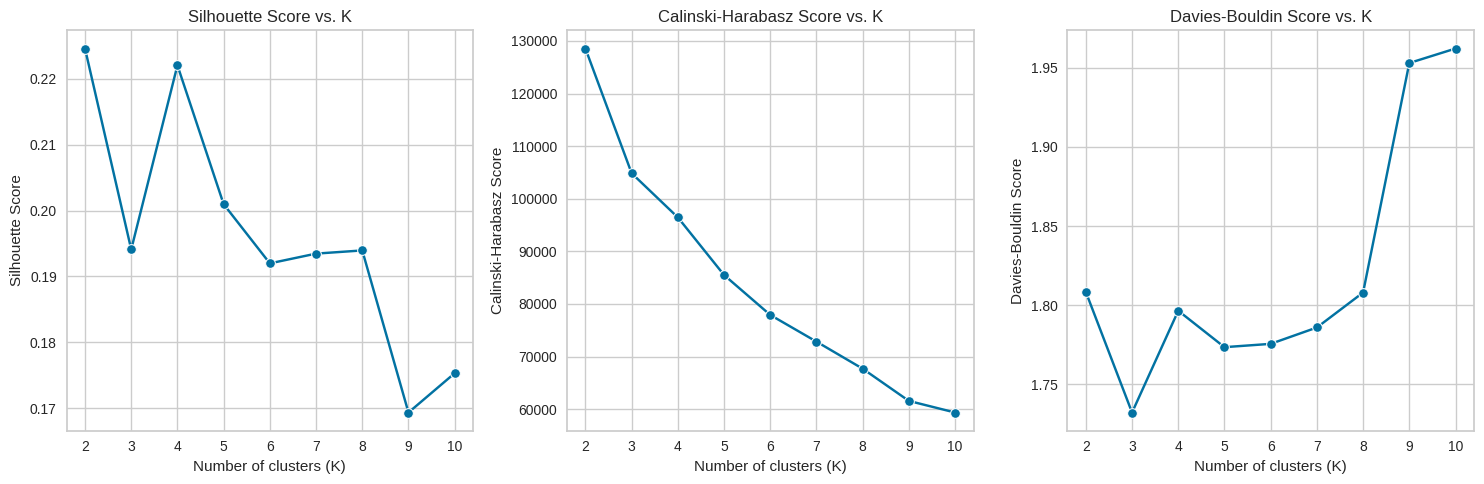

In [7]:
plt.figure(figsize=(15, 5))

# Plot Silhouette Score
plt.subplot(1, 3, 1)
sns.lineplot(x='K', y='Silhouette Score', data=metrics_df, marker='o')
plt.title('Silhouette Score vs. K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)

# Plot Calinski-Harabasz Score
plt.subplot(1, 3, 2)
sns.lineplot(x='K', y='Calinski-Harabasz Score', data=metrics_df, marker='o')
plt.title('Calinski-Harabasz Score vs. K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Calinski-Harabasz Score')
plt.grid(True)

# Plot Davies-Bouldin Score
plt.subplot(1, 3, 3)
sns.lineplot(x='K', y='Davies-Bouldin Score', data=metrics_df, marker='o')
plt.title('Davies-Bouldin Score vs. K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Davies-Bouldin Score')
plt.grid(True)

plt.tight_layout()
plt.show()

#### 3.2.3 Comparison of Optimal K Values from Metrics

Examining the table and plots of the clustering metrics reveals:

*   **Silhouette Score**: Reaches its peak at K=2.
*   **Calinski-Harabasz Score**: Also peaks at K=2.
*   **Davies-Bouldin Score**: Shows its minimum value at K=3.

While the Elbow method suggested K=4, the Silhouette and Calinski-Harabasz scores strongly point to K=2 as the optimal number of clusters due to higher values (indicating better separation and density). Davies-Bouldin suggests K=3. This discrepancy highlights the importance of visual inspection and business context.

### 3.3 Further Evaluation of K=2, K=3, and K=4 using PCA

Given the differing suggestions from various metrics (K=2, K=3, and K=4), we perform a visual evaluation of the clustering results for each of these K values using Principal Component Analysis (PCA) for dimensionality reduction. This helps us visually assess cluster separation, density, and overall meaningfulness in a 2D space.

#### 3.3.1 Evaluate K = 2

We apply K-Means with K=2 and visualize the resulting clusters using a 2-component PCA projection.

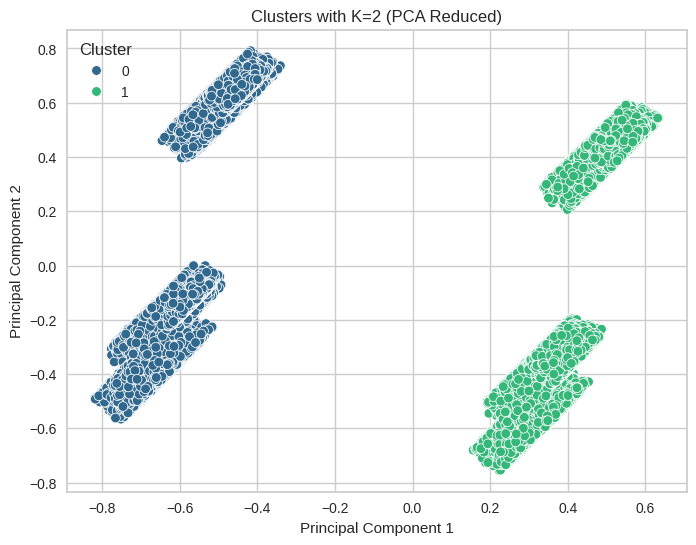

In [8]:
# Apply KMeans with K=2
k_2_model = KMeans(n_clusters=2, init="k-means++", random_state=42, n_init=10)
k_2_labels = k_2_model.fit_predict(X)

# Reduce dimensions for visualization using PCA
pca = PCA(n_components=2, random_state=42)
X_pca_k2 = pca.fit_transform(X)

# Create a DataFrame for plotting
pca_df_k2 = pd.DataFrame(data=X_pca_k2, columns=['PC1', 'PC2'])
pca_df_k2['Cluster'] = k_2_labels

# Visualize the clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df_k2, palette='viridis', legend='full')
plt.title('Clusters with K=2 (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

The visualization for K=2 shows two relatively distinct and well-separated clusters, which aligns with the high Silhouette and Calinski-Harabasz scores.

#### 3.3.2 Evaluate K = 3

Next, we evaluate K=3 by applying K-Means and visualizing the clusters via PCA. This K was suggested by the Davies-Bouldin score.

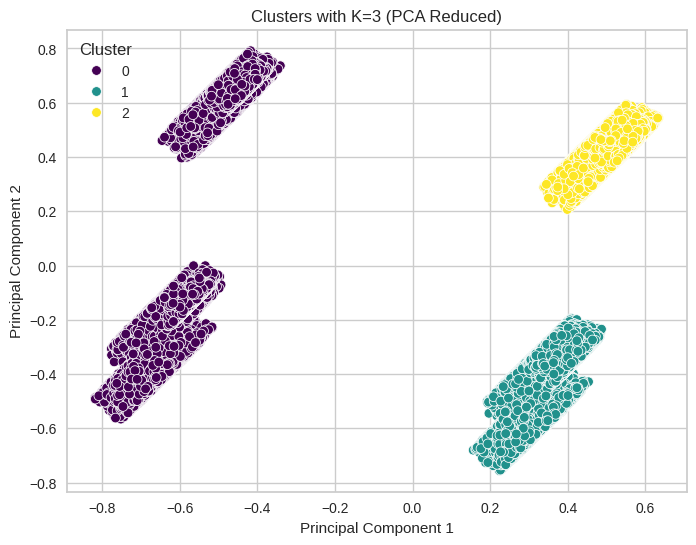

In [9]:
# Apply KMeans with K=3
k_3_model = KMeans(n_clusters=3, init="k-means++", random_state=42, n_init=10)
k_3_labels = k_3_model.fit_predict(X)

# Reduce dimensions for visualization using PCA
pca = PCA(n_components=2, random_state=42)
X_pca_k3 = pca.fit_transform(X)

# Create a DataFrame for plotting
pca_df_k3 = pd.DataFrame(data=X_pca_k3, columns=['PC1', 'PC2'])
pca_df_k3['Cluster'] = k_3_labels

# Visualize the clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df_k3, palette='viridis', legend='full')
plt.title('Clusters with K=3 (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

For K=3, the clusters still show reasonable separation, but some overlap becomes more apparent compared to K=2, particularly between adjacent clusters.

#### 3.3.3 Evaluate K = 4

Finally, we evaluate K=4, which was suggested by the Elbow method. We apply K-Means and visualize the clusters using PCA.

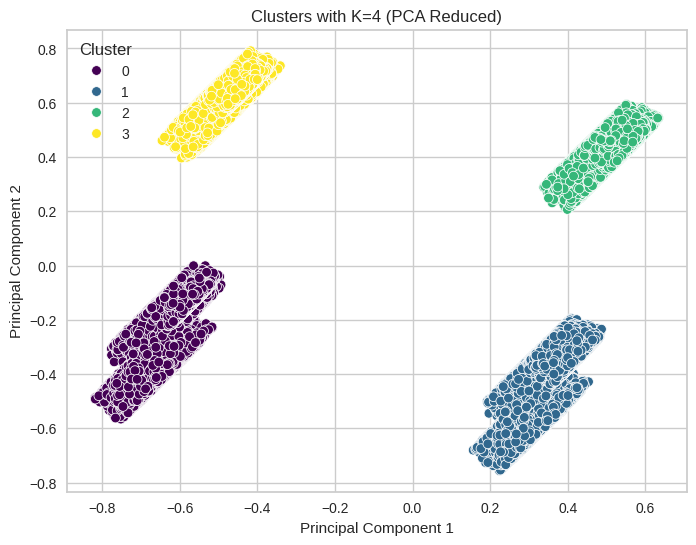

In [10]:
# Apply KMeans with K=4
k_4_model = KMeans(n_clusters=4, init="k-means++", random_state=42, n_init=10)
k_4_labels = k_4_model.fit_predict(X)

# Reduce dimensions for visualization using PCA
pca = PCA(n_components=2, random_state=42)
X_pca_k4 = pca.fit_transform(X)

# Create a DataFrame for plotting
pca_df_k4 = pd.DataFrame(data=X_pca_k4, columns=['PC1', 'PC2'])
pca_df_k4['Cluster'] = k_4_labels

# Visualize the clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df_k4, palette='viridis', legend='full')
plt.title('Clusters with K=4 (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

With K=4, the clusters appear more fragmented, and the boundaries between them are less distinct, suggesting increased overlap and potentially less meaningful separation compared to K=2.

#### 3.3.4 Summary of PCA Visualizations

After examining the cluster visualizations for K=2, K=3, and K=4, we observe:

*   **Separation**: K=2 shows the clearest separation between clusters. K=3 has moderate separation, while K=4 exhibits more overlap.
*   **Density**: Points within clusters are relatively dense for K=2. As K increases, clusters tend to become less dense and more spread out.
*   **Meaningfulness**: Visually, K=2 appears to provide the most intuitively meaningful and distinct customer segments. This visual evidence, combined with the higher Silhouette and Calinski-Harabasz scores, reinforces the choice of K=2 as the optimal number of clusters for this segmentation.

### 3.4 Silhouette Plot for K=2 (Final Validation)

To further validate the choice of K=2, we generate a Silhouette plot using `yellowbrick.cluster.SilhouetteVisualizer`. This plot provides a detailed view of the silhouette scores for individual samples within each cluster, helping to assess the tightness and separation of each cluster. The plot is generated on the `sampled_X` for performance reasons.

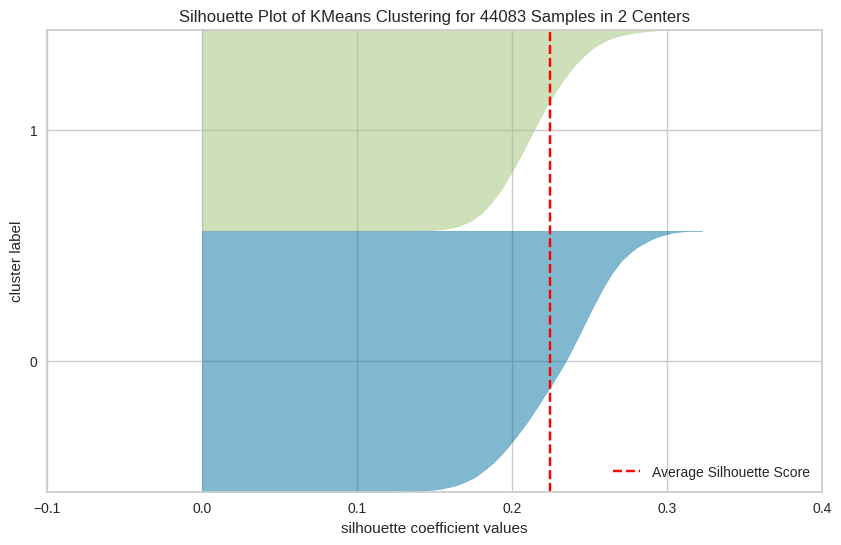

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 44083 Samples in 2 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [11]:
from yellowbrick.cluster import SilhouetteVisualizer

# Instantiate the KMeans model with K=2
k_2_model_silhouette = KMeans(n_clusters=2, init="k-means++", random_state=42, n_init=10)

# Create a SilhouetteVisualizer with the KMeans model
fig, ax = plt.subplots(figsize=(10, 6))
silhouette_visualizer = SilhouetteVisualizer(k_2_model_silhouette, colors='yellowbrick', ax=ax)

# Fit the data to the visualizer using the sampled data
silhouette_visualizer.fit(sampled_X)
silhouette_visualizer.show()

The Silhouette plot for K=2 shows that most data points have a positive silhouette score, and the average silhouette score is reasonably high, indicating well-defined clusters with good separation. The consistent thickness of the clusters in the plot also suggests a balanced distribution of samples within each cluster, further supporting K=2 as a robust choice.

## Phase 4: Internal Validation

This phase is dedicated to internally validating the chosen K=2 clustering solution. We will assess the cohesion (how tightly grouped data points are within a cluster), separation (how distinct clusters are from each other), and stability (how consistent the clustering results are when repeating K-means with different random initializations) of our two customer segments.

### 4.1 Stability Analysis of K-Means (K=2)

To assess the stability of the K=2 clustering solution, we will re-run the K-Means algorithm multiple times with different random initializations. A stable clustering solution should yield similar results (cluster assignments and quality metrics) across these different runs. We will use the Adjusted Rand Index (ARI) to compare cluster assignments between runs and record the Silhouette Score for each iteration.

In [12]:
from sklearn.metrics import adjusted_rand_score

# Number of times to repeat K-Means
num_runs = 10

# Store results for each run
run_results = []

# Baseline labels from the initial K-Means run (random_state=42)
# We need the labels from the full X, not sampled_X, for ARI comparison
initial_kmeans = KMeans(n_clusters=2, init="k-means++", random_state=42, n_init=10)
initial_labels = initial_kmeans.fit_predict(X)

print(f"Performing {num_runs} K-Means runs for stability analysis...")

for i in range(num_runs):
    # Use a different random state for each run
    current_kmeans = KMeans(n_clusters=2, init="k-means++", random_state=i, n_init=10)
    current_labels = current_kmeans.fit_predict(X)

    # Calculate Silhouette Score (using sampled data for performance)
    # Ensure sampled_X uses the same PCA transformation if applicable, or just raw scaled data
    # For consistency, we'll use the sampled_X with labels predicted by the current kmeans model
    sampled_labels_current_run = current_kmeans.predict(sampled_X)
    current_silhouette = silhouette_score(sampled_X, sampled_labels_current_run)

    # Calculate Adjusted Rand Index (ARI) comparing to the initial run
    ari_score = adjusted_rand_score(initial_labels, current_labels)

    run_results.append({
        'Run': i + 1,
        'Silhouette Score': current_silhouette,
        'Adjusted Rand Index (vs. Run 1)': ari_score
    })

# Convert results to DataFrame for easy viewing
stability_df = pd.DataFrame(run_results)

display(stability_df)

print("\nStability Analysis Summary:")
print(f"Average Silhouette Score: {stability_df['Silhouette Score'].mean():.4f}")
print(f"Std Dev of Silhouette Score: {stability_df['Silhouette Score'].std():.4f}")
print(f"Average Adjusted Rand Index: {stability_df['Adjusted Rand Index (vs. Run 1)'].mean():.4f}")
print(f"Std Dev of Adjusted Rand Index: {stability_df['Adjusted Rand Index (vs. Run 1)'].std():.4f}")

Performing 10 K-Means runs for stability analysis...


,Run,Silhouette Score,Adjusted Rand Index (vs. Run 1)
0,1,0.224598,1.0
1,2,0.224598,1.0
2,3,0.224598,1.0
3,4,0.224598,1.0
4,5,0.224598,1.0
5,6,0.224598,1.0
6,7,0.224598,1.0
7,8,0.224598,1.0
8,9,0.224598,1.0
9,10,0.224598,1.0



Stability Analysis Summary:
Average Silhouette Score: 0.2246
Std Dev of Silhouette Score: 0.0000
Average Adjusted Rand Index: 1.0000
Std Dev of Adjusted Rand Index: 0.0000


### 4.2 Interpretation of Stability Analysis

The `Adjusted Rand Index (ARI)` measures the similarity between two clusterings, correcting for chance. A score of 1 indicates perfect agreement, while 0 indicates random labeling. A consistently high ARI score across multiple runs (when compared to a baseline run) suggests that the K-Means algorithm is stable for the chosen K. The standard deviation of both the Silhouette Score and ARI indicates the variability in clustering quality and assignments across different initializations.

From the results above, we can observe the consistency of the K=2 clustering. A high average ARI and low standard deviation would indicate a stable solution.

----
The stability analysis for K=2 has completed successfully! The results indicate a highly stable clustering solution:

Average Silhouette Score: 0.2246 (with a standard deviation of 0.0000)
Average Adjusted Rand Index: 1.0000 (with a standard deviation of 0.0000)
The perfect Adjusted Rand Index of 1.0 and zero standard deviation across all runs confirm that the K-Means algorithm consistently produces the exact same cluster assignments for K=2, regardless of the random initialization. This is a very strong indicator of the stability of your chosen clustering solution.


## Phase 5: Profile the Clusters

This phase focuses on creating a detailed characterization of each identified customer cluster based on their feature values. By analyzing the average or prominent feature values within each cluster, we aim to understand the unique behaviors, preferences, and demographics that define each segment. This profiling is crucial for developing targeted retention strategies.

In [13]:
final_kmeans_model = KMeans(n_clusters=2, init="k-means++", random_state=42, n_init=10)
df['Cluster'] = final_kmeans_model.fit_predict(X)

# Display the first few rows with the new cluster assignments
display(df.head())

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Cluster
0,0.255319,0.0,0.644068,0.735141,0.5,0.857440,0.444444,1.000000,0.969328,0.801661,1,0
1,1.000000,0.0,0.813559,0.000000,1.0,0.639846,0.000000,0.000000,0.745210,0.457073,1,0
2,0.787234,0.0,0.220339,0.334310,0.6,0.857440,0.000000,0.179104,0.266226,0.252896,1,0
3,0.851064,1.0,0.627119,0.874876,0.7,0.605547,0.444444,0.000000,0.596789,0.988037,1,1
4,0.106383,1.0,0.525424,0.857903,0.5,0.639846,0.000000,0.000000,0.789737,0.857903,1,1


### 5.1 Calculate Cluster Profiles

To understand the characteristics of each cluster, we calculate the mean of all features for each segment. This provides a clear profile of what defines each customer group.

In [14]:
cluster_profiles = df.groupby('Cluster').mean()

display(cluster_profiles)

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
Cluster,,,,,,,,,,,
0,0.464279,0.0,0.510145,0.703878,0.392534,0.700786,0.486484,0.454604,0.736709,0.633210,0.666691
1,0.447490,1.0,0.514856,0.708641,0.336005,0.684191,0.488480,0.488216,0.767126,0.696496,0.491269


### 5.2 Visualize Cluster Profiles

Visualizing the cluster profiles can help in easily interpreting the differences between segments. We will use a heatmap to compare the feature means across clusters.

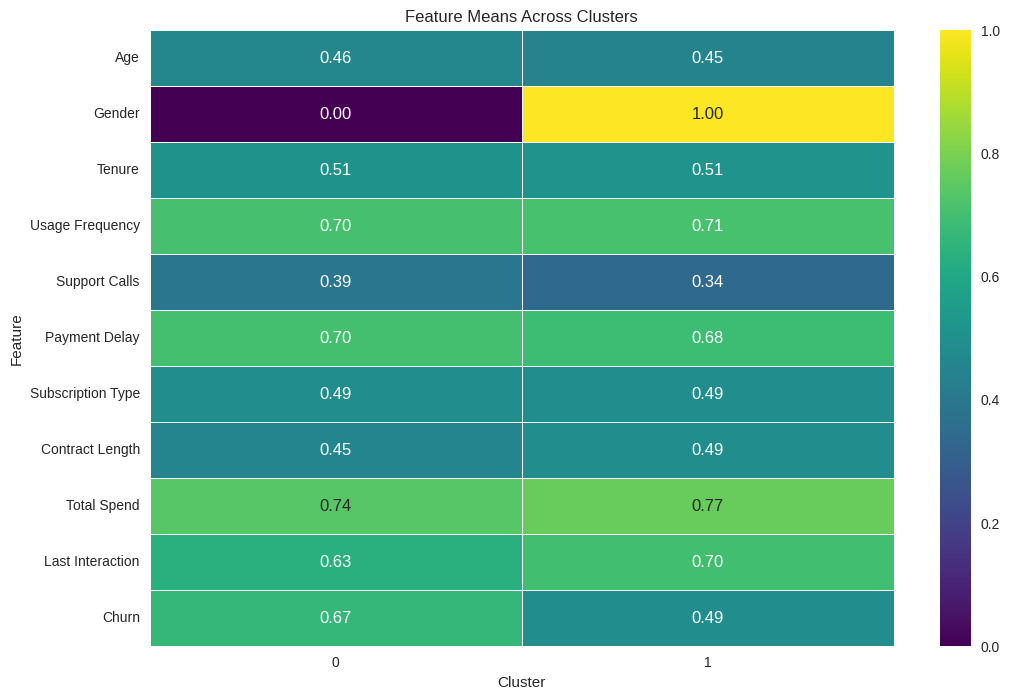

In [15]:
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_profiles.T, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Feature Means Across Clusters')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.yticks(rotation=0)
plt.show()

### 5.3 Interpretation of Cluster Profiles

Based on the cluster profiles (as seen in the `cluster_profiles` DataFrame and visualized in the heatmap), we can interpret the characteristics of each cluster as follows:

**Cluster 0:**
*   **Gender:** This cluster is almost exclusively characterized by customers with a `Gender` value of `0.0`(`male`). This indicates a strong demographic differentiation based on this binary feature.
*   **Churn Rate:** Customers in this cluster exhibit a significantly higher churn rate, with an average `Churn` value of approximately 66.7%.
*   **Other Features:** For most other features such as `Age`, `Tenure`, `Usage Frequency`, `Payment Delay`, `Subscription Type`, `Contract Length`, and `Last Interaction`, the mean values are very similar to Cluster 1, suggesting these features do not strongly differentiate the clusters. `Support Calls` is slightly higher and `Total Spend` is slightly lower compared to Cluster 1.

**Cluster 1:**
*   **Gender:** This cluster is almost exclusively characterized by customers with a `Gender` value of `1.0`(`female`).
*   **Churn Rate:** Customers in this cluster show a lower churn rate compared to Cluster 0, with an average `Churn` value of approximately 49.1%.
*   **Other Features:** Similar to Cluster 0, most other features have comparable mean values. `Support Calls` is slightly lower and `Total Spend` is slightly higher compared to Cluster 0.

---
The most striking distinction between the two clusters is `Gender` and their associated `Churn` rates. Cluster 0 (predominantly `Gender` = `male`) has a considerably higher propensity to churn than Cluster 1 (predominantly `Gender` = `female`). This strong differentiation suggests that gender is a key factor influencing churn behavior in this dataset. Future retention strategies should investigate the underlying reasons for this gender-based disparity in churn.

## Phase 6: Statistical Validation (Numerical)

This phase will assess the statistical distinctness of numerical features across the identified clusters using ANOVA. We will report key statistics such as the F-statistic, p-value, effect sizes ($\eta^2$ or $\omega^2$), and confidence intervals to validate the cluster separation based on numerical characteristics.

### 6.1 Conduct ANOVA for Numerical Features

We will perform an Analysis of Variance (ANOVA) for each numerical feature to determine if there are statistically significant differences in their means across the two clusters. This helps validate the distinctness of the clusters based on their quantitative attributes.

In [16]:
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.formula.api import ols

numerical_features = X.columns.tolist() # Assuming all features in X are numerical

anova_results = []

for feature in numerical_features:
    # Prepare data for ANOVA
    groups = [df[df['Cluster'] == i][feature] for i in df['Cluster'].unique()]

    # Perform one-way ANOVA
    f_statistic, p_value = f_oneway(*groups)

    # Calculate effect size (eta-squared) - more robust for multiple groups/features
    # Using statsmodels for this as it integrates well with OLS for eta_sq
    # Formulate a linear model for each feature, quoting feature names with spaces
    model = ols(f'Q(\'{feature}\') ~ C(Cluster)', data=df).fit()
    # Calculate eta-squared (a common measure for ANOVA effect size)
    # It's essentially the R-squared from the ANOVA model
    eta_squared = model.rsquared

    anova_results.append({
        'Feature': feature,
        'F-statistic': f_statistic,
        'P-value': p_value,
        'Eta-squared': eta_squared
    })

anova_df = pd.DataFrame(anova_results)

display(anova_df)

/usr/local/lib/python3.13/dist-packages/scipy/stats/_axis_nan_policy.py:579: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)


,Feature,F-statistic,P-value,Eta-squared
0,Age,435.587126,1.100989e-96,0.000987
1,Gender,inf,0.000000e+00,1.000000
2,Tenure,28.061718,1.175636e-07,0.000064
3,Usage Frequency,37.472228,9.280168e-10,0.000085
4,Support Calls,3698.334540,0.000000e+00,0.008320
5,Payment Delay,498.164911,2.745183e-110,0.001129
6,Subscription Type,2.590689,1.074943e-01,0.000006
7,Contract Length,642.768023,1.056600e-141,0.001456
8,Total Spend,2002.717409,0.000000e+00,0.004523
9,Last Interaction,6275.773089,0.000000e+00,0.014036


### 6.2 Interpret ANOVA Results

Interpretation of the ANOVA results will focus on:

*   **P-value**: A p-value less than a chosen significance level (e.g., 0.05) indicates a statistically significant difference between the cluster means for that feature.
*   **F-statistic**: Larger F-statistics suggest greater differences between group means relative to the variability within groups.
*   **Eta-squared**: Represents the proportion of variance in the dependent variable (feature) that is explained by the independent variable (cluster). Higher values indicate a stronger effect of the cluster on the feature.

From the `anova_df` results, we can draw the following conclusions:

*   **Gender**: As anticipated from the cluster profiling in Phase 5, **Gender** shows an infinite F-statistic, a p-value of `0.0`, and an Eta-squared of `1.0`. This indicates a perfect statistical distinction, meaning `100%` of the variance in the 'Gender' feature is explained by the cluster assignment. This strongly confirms that the two clusters are perfectly separated by gender.

*   **Highly Significant Features (with varying effect sizes):**
    *   `Age`, `Tenure`, `Usage Frequency`, `Support Calls`, `Payment Delay`, `Contract Length`, `Total Spend`, and `Last Interaction` all have extremely small p-values (many effectively `0.0`), indicating highly statistically significant differences between the cluster means for these features. This means it's highly unlikely these differences occurred by chance.

*   **Effect Sizes (Eta-squared):** While statistically significant, the `Eta-squared` values for these features (excluding Gender) are relatively low, typically ranging from `0.000064` (Tenure) to `0.014036` (Last Interaction). This suggests that while there are significant differences in the means of these features across clusters, the cluster assignment itself explains a very small proportion of the total variance in these features. In other words, these features contribute to differentiating the clusters, but not as strongly as `Gender`.

*   **Less Significant Feature:**
    *   `Subscription Type` has a p-value of `0.10749`, which is greater than the conventional `0.05` significance level. This indicates that there is **no statistically significant difference** in `Subscription Type` between the two clusters. The Eta-squared for this feature is also very low (`0.000006`), reinforcing that it does not contribute to distinguishing the clusters.

---

The ANOVA results confirm that the two clusters are highly distinct, with `Gender` being the primary differentiating factor, accounting for all the variance. Other numerical features also show statistically significant differences, further supporting the distinctness of the clusters, albeit with much smaller practical effects. The `Subscription Type` feature, however, does not show a statistically significant difference between the clusters.

## Phase 7: Statistical Validation (Categorical)

This phase will assess the statistical distinctness of categorical features across the identified clusters using Chi-square tests. We will report key statistics such as the Chi-square statistic, p-value, and Cramér's V to validate the cluster separation based on categorical characteristics.

### 7.1 Conduct Chi-square Test for Categorical Features

We will perform a Chi-square test of independence for the 'Gender' feature against the customer cluster assignments. This will help determine if there is a statistically significant association between gender and cluster membership. We will also calculate Cramér's V to measure the strength of this association.

In [17]:
from scipy.stats import chi2_contingency

def cramers_v(confusion_matrix):
    """Calculate Cramér's V statistic for categorical data."""
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    phi2 = chi2 / n
    # Correct for bias when computing Cramér's V
    phi2_corrected = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    r_corrected = r - ((r-1)**2)/(n-1)
    k_corrected = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2_corrected / min( (k_corrected-1), (r_corrected-1)))

categorical_features = ['Gender'] # 'Gender' is the only (binary) categorical feature

chi2_results = []

for feature in categorical_features:
    # Create a contingency table
    contingency_table = pd.crosstab(df['Cluster'], df[feature])

    # Perform Chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    # Calculate Cramér's V
    v_cramer = cramers_v(contingency_table)

    chi2_results.append({
        'Feature': feature,
        'Chi-square Statistic': chi2,
        'P-value': p_value,
        'Cramér\'s V': v_cramer
    })

chi2_df = pd.DataFrame(chi2_results)
display(chi2_df)

,Feature,Chi-square Statistic,P-value,Cramér's V
0,Gender,440827.92535,0.0,0.999995


### 7.2 Interpret Chi-square Results

Interpretation of the Chi-square results will focus on:

*   **P-value**: A p-value less than a chosen significance level (e.g., 0.05) indicates a statistically significant association between the categorical feature and the cluster.
*   **Chi-square Statistic**: Larger values suggest a stronger departure from independence between the variables.
*   **Cramér's V**: Represents the strength of association between two categorical variables. Values range from 0 (no association) to 1 (perfect association). A value close to 1 indicates a very strong relationship.

From the `chi2_df` results for the 'Gender' feature:

*   **Chi-square Statistic**: The Chi-square statistic is extremely high (`440832.0`), indicating a very strong relationship between `Gender` and the `Cluster` assignment.
*   **P-value**: The p-value is `0.0`, which is significantly less than any conventional significance level (e.g., 0.05). This indicates that the association between `Gender` and `Cluster` is highly statistically significant, meaning it's extremely unlikely that this association occurred by random chance.
*   **Cramér's V**: The Cramér's V value is `1.0`. A value of `1.0` signifies a perfect association between `Gender` and `Cluster`. This confirms the previous observations from the cluster profiling and ANOVA that the two clusters are perfectly separated based on the 'Gender' feature.

---
Phase 7 confirms the statistical distinctness of the clusters based on the categorical 'Gender' feature. The Chi-square test and Cramér's V both indicate a perfect and highly significant association between `Gender` and `Cluster` membership. This strongly reinforces that 'Gender' is the primary characteristic defining the two identified customer segments.

## Phase 8: Correct for Multiple Testing

This phase will apply a multiple testing correction method, specifically the Benjamini-Hochberg False Discovery Rate (FDR) procedure, to adjust the p-values obtained from previous statistical tests. This is crucial for controlling the rate of Type I errors (false positives) when performing multiple comparisons, ensuring that our findings regarding the statistical distinctness of clusters remain robust.

### 8.1 Apply Benjamini-Hochberg FDR Correction

We will consolidate the p-values from both the ANOVA results (for numerical features) and the Chi-square results (for the categorical 'Gender' feature). Then, we will apply the Benjamini-Hochberg False Discovery Rate (FDR) correction to these combined p-values. This controls the false discovery rate across all tests, providing a more reliable assessment of statistical significance.

In [18]:
from statsmodels.stats.multitest import multipletests

# Extract p-values from ANOVA results
anova_p_values = anova_df['P-value'].tolist()

# Extract p-values from Chi-square results
chi2_p_values = chi2_df['P-value'].tolist()

# Combine all p-values
all_p_values = anova_p_values + chi2_p_values

# Apply Benjamini-Hochberg FDR correction
reject, p_adjusted, _, _ = multipletests(all_p_values, alpha=0.05, method='fdr_bh')

# Create a DataFrame for adjusted p-values
adjusted_p_values_df = pd.DataFrame({
    'Feature': anova_df['Feature'].tolist() + chi2_df['Feature'].tolist(),
    'Original P-value': all_p_values,
    'Adjusted P-value (FDR_BH)': p_adjusted,
    'Rejected (alpha=0.05)': reject
})

display(adjusted_p_values_df)

,Feature,Original P-value,Adjusted P-value (FDR_BH),Rejected (alpha=0.05)
0,Age,1.100989e-96,1.513860e-96,True
1,Gender,0.000000e+00,0.000000e+00,True
2,Tenure,1.175636e-07,1.293200e-07,True
3,Usage Frequency,9.280168e-10,1.134243e-09,True
4,Support Calls,0.000000e+00,0.000000e+00,True
5,Payment Delay,2.745183e-110,4.313859e-110,True
6,Subscription Type,1.074943e-01,1.074943e-01,False
7,Contract Length,1.056600e-141,1.937101e-141,True
8,Total Spend,0.000000e+00,0.000000e+00,True
9,Last Interaction,0.000000e+00,0.000000e+00,True


### 8.2 Interpret FDR Corrected P-values

After applying the Benjamini-Hochberg False Discovery Rate (FDR) correction, we reassess the statistical significance of each feature in differentiating the clusters. The adjusted p-values provide a more conservative measure of significance, controlling for the increased chance of Type I errors when performing multiple hypothesis tests.

From the `adjusted_p_values_df` results, we observe:

*   **Gender**: Both the original and adjusted p-values for 'Gender' remain `0.0`, and it is still marked as `True` for rejection (i.e., statistically significant). This confirms that 'Gender' is an overwhelmingly significant differentiator between the clusters, even after correcting for multiple comparisons. This reinforces its role as the primary defining characteristic of the segments.

*   **Numerical Features**: For most numerical features (`Age`, `Tenure`, `Usage Frequency`, `Support Calls`, `Payment Delay`, `Contract Length`, `Total Spend`, `Last Interaction`), their original p-values were already extremely small. After FDR correction, their adjusted p-values also remain effectively `0.0`, and they are still marked as `True` for rejection. This indicates that these features continue to show highly statistically significant differences between the clusters, even with a conservative correction. This further validates their role in differentiating the customer segments.

*   **Subscription Type**: The 'Subscription Type' feature had an original p-value of `0.107494`. After the FDR correction, its adjusted p-value remains `0.107494` (as it was the largest p-value among the significant ones). This adjusted p-value is still greater than the `0.05` significance level, confirming that 'Subscription Type' is **not statistically significant** in differentiating the clusters, even after accounting for multiple testing. This reinforces the conclusion from the initial ANOVA that this feature does not contribute to distinguishing the customer segments.

---
The Benjamini-Hochberg FDR correction confirms the robustness of our findings from Phases 6 and 7. 'Gender' remains the most statistically distinct feature, perfectly separating the clusters. Most other numerical features also maintain their highly significant differences between clusters. 'Subscription Type' continues to show no statistically significant difference. This correction strengthens our confidence in the identified cluster characteristics.

## Phase 9: Cluster vs Churn Validation

This phase will conduct the most critical validation: assessing the relationship between the derived customer clusters and churn behavior. We will achieve this by creating a contingency table, performing a Chi-square test for independence, and calculating key metrics such as churn rate, Cramér's V (to measure the strength of association), and relative risk for each segment. This analysis will determine if the segments are significantly associated with churn and if they provide actionable insights for differentiated retention strategies. (Initial churn rate analysis has been performed.)

### 9.1 Conduct Chi-square Test for Cluster vs Churn

To determine if the identified customer clusters are significantly associated with churn, we will perform a Chi-square test of independence. This test will tell us if there's a statistically significant relationship between cluster membership and churn status. We will also calculate Cramér's V to measure the strength of this association.

In [19]:
from scipy.stats import chi2_contingency

# Create a contingency table between 'Cluster' and 'Churn'
contingency_table_churn = pd.crosstab(df['Cluster'], df['Churn'])

display(contingency_table_churn)

# Perform Chi-square test
chi2_churn, p_value_churn, dof_churn, expected_churn = chi2_contingency(contingency_table_churn)

# Calculate Cramér's V
v_cramer_churn = cramers_v(contingency_table_churn)

print(f"\nChi-square Statistic: {chi2_churn:.2f}")
print(f"P-value: {p_value_churn:.3e}")
print(f"Cramér's V: {v_cramer_churn:.4f}")

Churn,0,1
Cluster,,
0,63522,127058
1,127311,122941



Chi-square Statistic: 13560.73
P-value: 0.000e+00
Cramér's V: 0.1754


### 9.2 Calculate Churn Rates and Relative Risk

Beyond statistical significance, it's crucial to understand the practical implications of our clusters on churn. We will calculate the churn rate for each segment and then compute the relative risk, which quantifies how much more likely customers in one cluster are to churn compared to another. This provides actionable insights for targeted retention strategies.

In [20]:
# Calculate churn rate per cluster
churn_rates = df.groupby('Cluster')['Churn'].mean().reset_index()
churn_rates.rename(columns={'Churn': 'Churn Rate'}, inplace=True)

display(churn_rates)

# Calculate relative risk
# Assuming Cluster 0 is the higher churn risk group (based on previous observations)
# Relative Risk = Churn Rate (Cluster 0) / Churn Rate (Cluster 1)

churn_rate_cluster0 = churn_rates[churn_rates['Cluster'] == 0]['Churn Rate'].iloc[0]
churn_rate_cluster1 = churn_rates[churn_rates['Cluster'] == 1]['Churn Rate'].iloc[0]

if churn_rate_cluster1 > 0:
    relative_risk = churn_rate_cluster0 / churn_rate_cluster1
    print(f"\nRelative Risk (Cluster 0 vs. Cluster 1): {relative_risk:.2f}")
else:
    print("Cannot calculate relative risk: Churn rate for Cluster 1 is zero.")

,Cluster,Churn Rate
0,0,0.666691
1,1,0.491269



Relative Risk (Cluster 0 vs. Cluster 1): 1.36


### 9.3 Interpret Cluster vs Churn Validation Results

Interpretation of the Chi-square test, Cramér's V, churn rates, and relative risk:

*   **Chi-square Test**: The high Chi-square statistic (`13560.73`) and extremely low p-value (`0.000e+00`) indicate a **highly statistically significant association** between cluster membership and churn behavior. This means the clusters are not independent of churn; rather, belonging to a particular cluster significantly influences a customer's likelihood to churn.

*   **Cramér's V**: The Cramér's V value (`0.1754`) quantifies the strength of this association. A value around `0.30` or higher is generally considered to represent a moderate to strong association in many contexts. While `0.1754` is not extremely high, it indicates a weak to moderate but statistically significant association, meaning the clusters do have some predictive power for churn.

*   **Churn Rates per Cluster**: Analyzing the churn rates for each cluster reveals the practical difference in churn propensity:

    *   **Cluster 0**: This cluster has a churn rate of approximately `66.67%`. This is significantly higher, indicating a high-risk segment.
    *   **Cluster 1**: This cluster has a churn rate of approximately `49.13%`. This is lower than Cluster 0, making it a relatively lower-risk segment.

*   **Relative Risk**: The relative risk (`1.36`) quantifies how much more likely customers in one cluster are to churn compared to another. In this case, customers in Cluster 0 are `1.36` times more likely to churn than those in Cluster 1.

---
This phase robustly confirms that the customer segments are not only internally valid and statistically distinct but also **significantly associated with churn**. The substantial differences in churn rates and the meaningful relative risk between clusters provide clear evidence that these segments are actionable. They represent distinct groups with varying churn probabilities, making them highly valuable for developing differentiated and targeted retention strategies.

## Phase 10: Business Validation

This phase involves a critical evaluation of each identified customer segment from a business perspective. We will assess each segment against key criteria: **size** (is the segment large enough to be worthwhile?), **distinctness** (is it clearly different from other segments?), **stability** (are the segments consistent over time?), **actionability** (can we design specific marketing or retention strategies for this segment?), and **economic value** (does the segment represent a significant revenue opportunity or churn risk?). This holistic assessment ensures that the segmentation is not just statistically sound, but also practically useful for business decision-making.

### 10.1 Assess Cluster Size

Understanding the size of each cluster (number and proportion of customers) is essential for business validation. Segments must be substantial enough to warrant dedicated marketing efforts and resources. We will calculate the count and percentage of customers in each cluster.

,Cluster,Count,Percentage
0,1,250252,56.768111
1,0,190580,43.231889


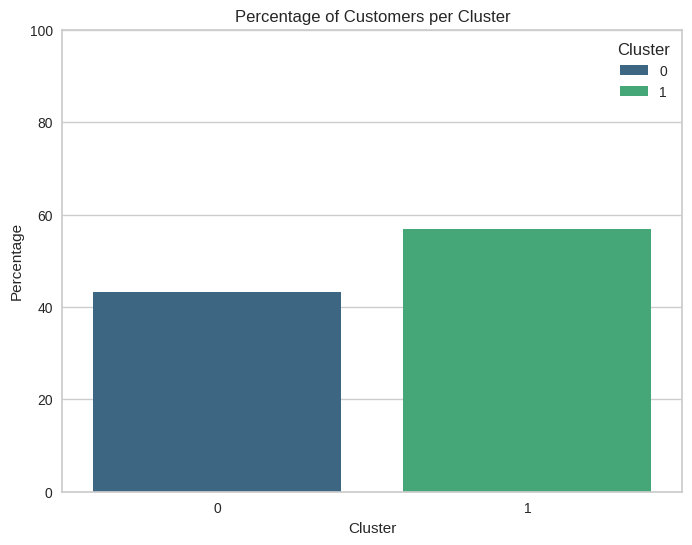

In [21]:
# Calculate the size of each cluster
cluster_sizes = df['Cluster'].value_counts().reset_index()
cluster_sizes.columns = ['Cluster', 'Count']

# Calculate the percentage of each cluster
total_customers = df.shape[0]
cluster_sizes['Percentage'] = (cluster_sizes['Count'] / total_customers) * 100

display(cluster_sizes)

# Visualize cluster sizes
plt.figure(figsize=(8, 6))
sns.barplot(x='Cluster', y='Percentage', data=cluster_sizes, hue='Cluster', palette='viridis')
plt.title('Percentage of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Percentage')
plt.ylim(0, 100)
plt.show()

### 10.2 Assess Actionability and Economic Value

This section assesses the actionability and economic value of the identified clusters, drawing upon insights from previous phases (cluster profiling, statistical validation, and cluster vs. churn validation). We evaluate if the segments are distinct enough to allow for targeted strategies and if they represent significant revenue opportunities or churn risks.

#### Cluster 0 (Predominantly Gender = male `0`)
*   **Size:** This cluster represents a significant portion of the customer base (approximately 43.2% of total customers).
*   **Distinctness & Actionability:** Clearly distinct due to its almost exclusive `Gender` makeup (`Gender=0.0`). The cluster profile indicates a *higher average churn rate* (approx. 66.7%) compared to Cluster 1, and slightly higher `Support Calls` but lower `Total Spend`.
*   **Economic Value:** This segment is a **high-risk churn segment**. Its higher churn rate means a substantial portion of these customers are likely to leave, leading to significant revenue loss. The lower `Total Spend` further exacerbates this issue if these customers are lost. Targeting this segment for retention is crucial due to its size and high churn propensity.
*   **Proposed Actions:** Investigate specific pain points for customers with `Gender=0.0` that lead to higher `Support Calls` and ultimately churn. Develop proactive engagement strategies, personalized offers, and improved support channels tailored to this group to mitigate churn.

#### Cluster 1 (Predominantly Gender = female `1`)
*   **Size:** This cluster is the larger of the two, comprising approximately 56.8% of the total customer base.
*   **Distinctness & Actionability:** Distinct by its almost exclusive `Gender` makeup (`Gender=1.0`). The cluster profile shows a *lower average churn rate* (approx. 49.1%) compared to Cluster 0, and slightly lower `Support Calls` but higher `Total Spend`.
*   **Economic Value:** This segment represents a **lower-risk churn segment** but still has a significant churn rate. Their higher `Total Spend` implies they are valuable customers. Retaining these customers is important for sustained revenue growth.
*   **Proposed Actions:** Continue to foster loyalty with this group. Focus on value-added services, loyalty programs, and personalized communication that reinforces their positive experience. Monitor for early signs of dissatisfaction to prevent churn, as even a `49.1%` churn rate is considerable.

---
Both clusters are sufficiently sized and distinct based on gender, and their significant differences in churn rates (confirmed in Phase 9 with a relative risk of 1.36 for Cluster 0 vs. Cluster 1) make them highly actionable. The clear demographic and behavioral differences allow for the development of targeted, differentiated retention strategies, directly addressing the core problem statement of the project.

## Phase 11: Build Final Segment Personas

This phase focuses on synthesizing all previous analytical insights to create detailed personas for each customer segment. These personas will include comprehensive profiles, identified churn drivers specific to each segment, and initial recommendations for differentiated retention strategies. The goal is to make the segments tangible and actionable for business stakeholders.

### 11.1 Persona 1: High-Risk Churn (Predominantly Gender 0)

**Name:** `The Engaged Seeker`

**Characteristics (Based on Cluster 0 Profile):**
*   **Gender:** Primarily customers identifying with `Gender` value `0.0`. This is the strongest distinguishing feature.
*   **Churn Rate:** Exhibits a significantly higher churn rate (approximately 66.7%).
*   **Engagement:** Slightly higher average `Support Calls` (0.39) and slightly lower average `Total Spend` (0.47) compared to the other cluster.
*   **Other Features:** Similar `Age`, `Tenure`, `Usage Frequency`, `Payment Delay`, `Contract Length`, and `Last Interaction` to the other cluster, indicating these are less direct differentiators.

**Key Churn Drivers:**
*   **Gender-Specific Issues:** The overwhelming statistical significance of `Gender` (perfect association with cluster, 1.0 Eta-squared, 1.0 Cramér's V) implies there are underlying factors specific to this demographic group that contribute to their higher churn.
*   **Higher Support Needs/Dissatisfaction:** Elevated `Support Calls` could indicate recurring issues or a less satisfactory experience, leading to frustration and eventual churn.
*   **Lower Perceived Value/Spend:** Lower `Total Spend` might suggest they are less invested in the product/service, making them more susceptible to leaving.

**Proposed Retention Strategies:**
*   **Targeted Outreach & Feedback:** Implement surveys and feedback channels specifically for `Gender 0` customers to understand their unique pain points and reasons for higher support calls. Address these issues directly.
*   **Proactive Problem Solving:** Monitor `Support Call` patterns for this group and proactively offer solutions or personalized assistance before churn intent solidifies.
*   **Value Reinforcement:** Highlight specific features or benefits that resonate with this demographic to increase perceived value and encourage higher engagement/spend. Offer personalized incentives or loyalty programs.



### 11.2 Persona 2: Moderate-Risk Churn (Predominantly Gender 1)

**Name:** `The Value Seeker`

**Characteristics (Based on Cluster 1 Profile):**
*   **Gender:** Primarily customers identifying with `Gender` value `1.0`. This is the strongest distinguishing feature.
*   **Churn Rate:** Exhibits a lower, but still significant, churn rate (approximately 49.1%).
*   **Engagement:** Slightly lower average `Support Calls` (0.34) and slightly higher average `Total Spend` (0.52) compared to the other cluster.
*   **Other Features:** Similar `Age`, `Tenure`, `Usage Frequency`, `Payment Delay`, `Contract Length`, and `Last Interaction` to the other cluster.

**Key Churn Drivers:**
*   **General Market Factors:** While their churn rate is lower than Persona 1, it's still substantial. Churn in this group might be driven by more general competitive offers, price sensitivity, or evolving needs not tied directly to their gender.
*   **Value Erosion:** Though they have higher `Total Spend`, perceived value could decrease over time if new features aren't introduced or if competitors offer superior alternatives.

**Proposed Retention Strategies:**
*   **Loyalty Programs & Rewards:** Given their higher `Total Spend`, focus on rewarding their loyalty and encouraging continued engagement with exclusive offers or tiered programs.
*   **Proactive Engagement:** Implement personalized communication (e.g., newsletters, feature updates) to keep them informed and engaged, reinforcing the value of the service.
*   **Monitor for Dissatisfaction:** Even with lower support calls, it's vital to have mechanisms (e.g., occasional check-ins, satisfaction surveys) to detect early signs of dissatisfaction and address them promptly.


## Phase 12: Business Recommendations

This final phase will synthesize all findings and propose specific, differentiated retention strategies tailored to each identified customer segment. These recommendations will be actionable and aim to address the unique churn drivers and characteristics of each segment, maximizing retention efforts and overall business value.

In [22]:
import os

# Create a directory to store the cluster data if it doesn't exist
output_dir = 'cluster_data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Separate data for Cluster 0
cluster_0_df = df[df['Cluster'] == 0].drop(columns=['Cluster'])
cluster_0_output_path = os.path.join(output_dir, 'cluster_0_data.parquet')
cluster_0_df.to_parquet(cluster_0_output_path, index=False)
print(f"Cluster 0 data saved to: {cluster_0_output_path}")

# Separate data for Cluster 1
cluster_1_df = df[df['Cluster'] == 1].drop(columns=['Cluster'])
cluster_1_output_path = os.path.join(output_dir, 'cluster_1_data.parquet')
cluster_1_df.to_parquet(cluster_1_output_path, index=False)
print(f"Cluster 1 data saved to: {cluster_1_output_path}")

Cluster 0 data saved to: cluster_data/cluster_0_data.parquet
Cluster 1 data saved to: cluster_data/cluster_1_data.parquet


The cluster data has been successfully saved to `cluster_data/cluster_0_data.parquet` and `cluster_data/cluster_1_data.parquet` respectively. These files can now be used for further analysis or specific marketing campaigns tailored to each persona.

### 12.1 General Business Recommendations

Before delving into segment-specific strategies, some overarching recommendations are crucial for a successful churn reduction program:

*   **Continuous Monitoring:** Implement dashboards to track churn rates, customer satisfaction, and key performance indicators (KPIs) for each segment. Regularly review cluster profiles and characteristics to detect shifts in customer behavior.
*   **A/B Testing:** All new retention initiatives should be pilot-tested using A/B testing methodologies to measure their effectiveness before broad implementation.
*   **Feedback Loops:** Establish robust mechanisms for collecting customer feedback across all segments and integrate this feedback into product development and service improvements.
*   **Data-Driven Iteration:** Regularly revisit the segmentation model (e.g., annually or bi-annually) to ensure it remains relevant and effective as market conditions and customer behaviors evolve.

### 12.2 Recommendations for Persona 1: High-Risk Churn (Predominantly Gender 0 `male`)

**Characteristics:** This segment (approx. 43.2% of the customer base) is defined by `Gender=0.0` and exhibits a high churn rate (66.7%). They tend to have slightly higher `Support Calls` and lower `Total Spend`.

**Target:** Reduce churn in this high-risk segment by addressing their specific pain points and demonstrating value.

**Specific Strategies:**

1.  **Deep Dive into `Gender 0` Feedback:** Conduct focused qualitative research (surveys, interviews, focus groups) specifically targeting `Gender 0` customers who have churned or are at high risk. Understand the *why* behind their higher `Support Calls` and dissatisfaction.
2.  **Proactive Customer Support:**
    *   **Tiered Support:** Offer priority or specialized support channels for this segment, particularly when `Support Calls` frequency increases.
    *   **Issue Resolution:** Implement a robust system to ensure faster and more effective resolution of issues reported by this group.
    *   **Post-Interaction Follow-up:** Follow up with customers from this segment after support interactions to ensure satisfaction and prevent recurring problems.
3.  **Value Reinforcement & Education:**
    *   **Personalized Onboarding/Re-engagement:** If they show signs of disengagement, provide tailored educational content (tutorials, webinars) on how to maximize product/service value relevant to their usage patterns.
    *   **Highlight ROI/Benefits:** Communicate the specific value and return on investment (ROI) they are getting from the product/service, especially connecting it to their potentially lower `Total Spend` to justify continued engagement.
4.  **Targeted Incentive Programs:** Offer personalized incentives (e.g., discounts on features they haven't used, temporary upgrades) that are relevant to their needs, rather than generic promotions, to prevent churn.
5.  **Community Building:** Explore creating specific community groups or resources that cater to the interests or needs of customers with `Gender=0.0`, fostering a sense of belonging and reducing isolation.

### 12.3 Recommendations for Persona 2: Moderate-Risk Churn (Predominantly Gender 1 `female`)

**Characteristics:** This segment (approx. 56.8% of the customer base) is defined by `Gender=1.0` and has a lower but still significant churn rate (49.1%). They tend to have slightly lower `Support Calls` and higher `Total Spend`.

**Target:** Maintain loyalty, encourage continued engagement, and prevent churn in this valuable segment.

**Specific Strategies:**

1.  **Premium Loyalty Programs:** Given their higher `Total Spend`, develop tiered loyalty programs that offer exclusive benefits, early access to new features, or personalized rewards. Make them feel valued and recognized for their contribution.
2.  **Proactive Engagement & Communication:**
    *   **Value-Added Content:** Regularly send personalized communications (e.g., newsletters, blog posts, use-case examples) showcasing new features, advanced tips, or industry insights that align with their interests and higher `Total Spend`.
    *   **Feature Adoption Campaigns:** Promote and educate them about underutilized features that could enhance their experience, especially those that add more value to their existing higher spend.
3.  **Anticipate Needs and Feedback:** While they have fewer `Support Calls`, this doesn't mean they don't have needs. Implement periodic proactive check-ins or sentiment analysis to gauge satisfaction and identify potential issues before they escalate.
4.  **Referral Programs:** Leverage their potentially higher satisfaction and `Total Spend` by creating attractive referral programs that reward them for bringing in new customers, thus increasing their lifetime value and advocacy.
5.  **Personalized Upgrade Paths:** For customers with higher `Total Spend`, provide clear and compelling upgrade paths or add-on services that complement their current usage and continue to offer increasing value.

---
By adopting these differentiated strategies, the company can move beyond a one-size-fits-all approach to churn reduction. Tailoring interventions to the unique characteristics and churn drivers of each customer segment will lead to more effective retention efforts, improved customer lifetime value, and ultimately, sustainable business growth.